# Chapter 9 — Spectral kernels versus trees: the capacity map

*Companion notebook to **The Learned Kernel**, Ch. 9. Run top to bottom.*

Chapter 4 showed a gradient-boosted forest **is** a kernel — its leaves induce a
positive-semidefinite leaf co-membership similarity. Chapter 8 built the spectral-Laplace
kernel from the other side, learning a spectral measure per feature and reading it out
through a rough exponential. Two **learned, axis-aligned** geometries of the same type. So
the practitioner's question is not "tree or kernel" but *which learned geometry fits the
structure in this target.*

We answer it with a head-to-head: both kernels decoded by **one** kernel-ridge head on a
support fold and scored on a held-out query fold, across a synthetic suite (S1 smooth,
S2 periodic, S9 degree-four interaction, S10 sharp partition) and California — plus an
**additive-Laplace** control (a sum of per-feature kernels) that carries main effects only.

**The frame** — *what is learned · how scored · what you read off.* What: two adaptive
geometries (the leaf partition and the per-feature spectral measure). Scored: each decoded
by one ridge under the leakage-free support/query split. Read off: a *capacity map* of which
knob bought which kind of fit.

## Setup

In [1]:
# On Google Colab (or any fresh env) install the companion package; no-op locally.
try:
    import lkbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        "learned-kernel[notebooks] @ git+https://github.com/asudjianto-xml/Learned-Kernel.git"],
        check=True)

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lkbook import set_style
from lkbook.chapters import ch09

set_style()

## 9.1  The smoothness ladder

Rank the readouts by the regularity of the function class they admit. The RBF (C^∞) is the
smoothest and **oversmooths** — its RKHS excludes a rough component entirely. The Laplace
readout (H^{(d+1)/2}, the cusp at the origin) is rough but continuous. The tree is
discontinuous, piecewise constant. On a smooth-plus-jump target the RBF rounds the kink, the
Laplace bends through the trend, and the tree captures the jump exactly.

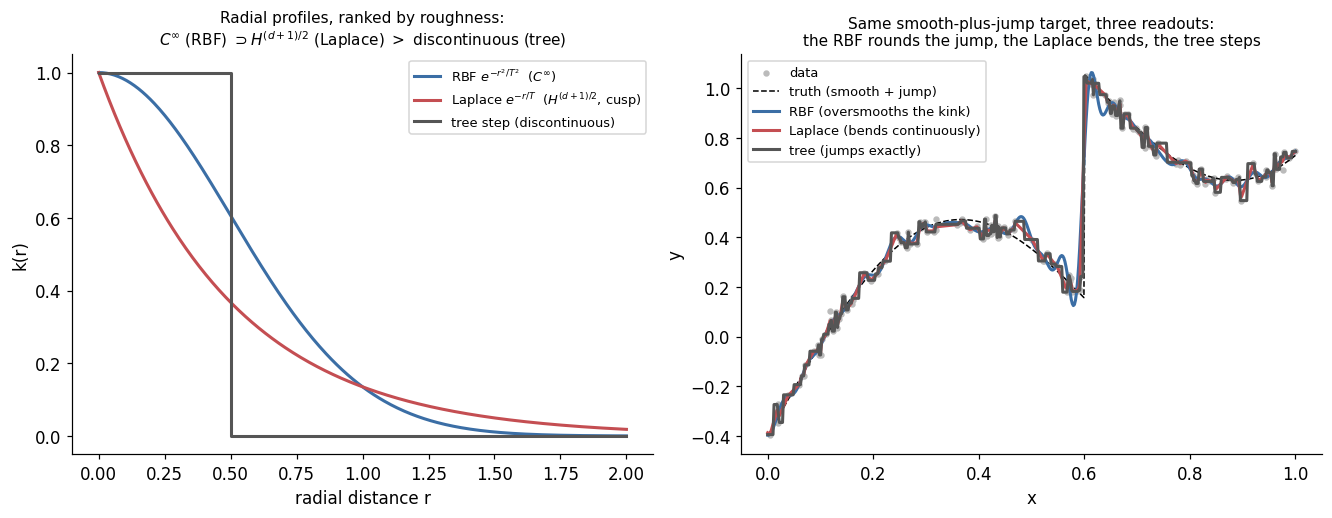

In [3]:
ch09.make_smoothness_ladder_figure()
plt.show()

## 9.2  The kernels are PSD with unit diagonal

Both the spectral-Laplace kernel and the additive-Laplace control are Gram matrices of an
explicit feature map, so PSD, and each is 1 on the diagonal.

In [4]:
# Chapter 9 imports Chapter 8's canonical kernel (`fit_spectral`, learned mode) and only adds the
# head-to-head. A few-step fit is enough to get a kernel object and check it is PSD, unit-diagonal.
X = np.random.RandomState(0).uniform(-1, 1, size=(60, 5))
y = X[:, 0] + X[:, 1]
k, _ = ch09.fit_spectral_mv(X, y, steps=10)                       # full (interaction) kernel
K = k.gram(X, X)
print(f"spectral-Laplace: diagonal mean {np.diag(K).mean():.3f}, "
      f"min eigenvalue {np.linalg.eigvalsh(K).min():.2e}  (>= 0 => PSD)")
kadd, _ = ch09.fit_additive_laplace(X, y, steps=10)               # order-one additive control
Kadd = kadd.gram(X, X)
print(f"additive-Laplace: diagonal mean {np.diag(Kadd).mean():.3f}, "
      f"min eigenvalue {np.linalg.eigvalsh(Kadd).min():.2e}")

/home/asudjianto/cluster/spark-venv/lib/python3.12/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  queued_call()


spectral-Laplace: diagonal mean 1.000, min eigenvalue 8.87e-01  (>= 0 => PSD)
additive-Laplace: diagonal mean 1.000, min eigenvalue 2.08e-01


## 9.3  The head-to-head — the win/lose map

Run all three kernels on every target under the shared decoder. The map reproduces the
capacity map: spectral wins the smooth, periodic and high-order-interaction targets; the
tree wins the discontinuous one (and edges out California); the additive control is worst on
the interaction it cannot represent.

In [5]:
rows = ch09.run_capacity_map()
tbl = pd.DataFrame(rows)[["label", "spectral", "tree", "additive", "winner"]]
tbl = tbl.round({"spectral": 3, "tree": 3, "additive": 3})
tbl

,label,spectral,tree,additive,winner
0,S1 smooth,0.075,0.102,0.071,spectral
1,S2 periodic,0.074,0.116,0.070,spectral
2,S9 deg-4,0.370,1.134,1.048,spectral
3,S10 jumps,0.582,0.519,1.024,tree
4,California,0.438,0.506,0.507,spectral


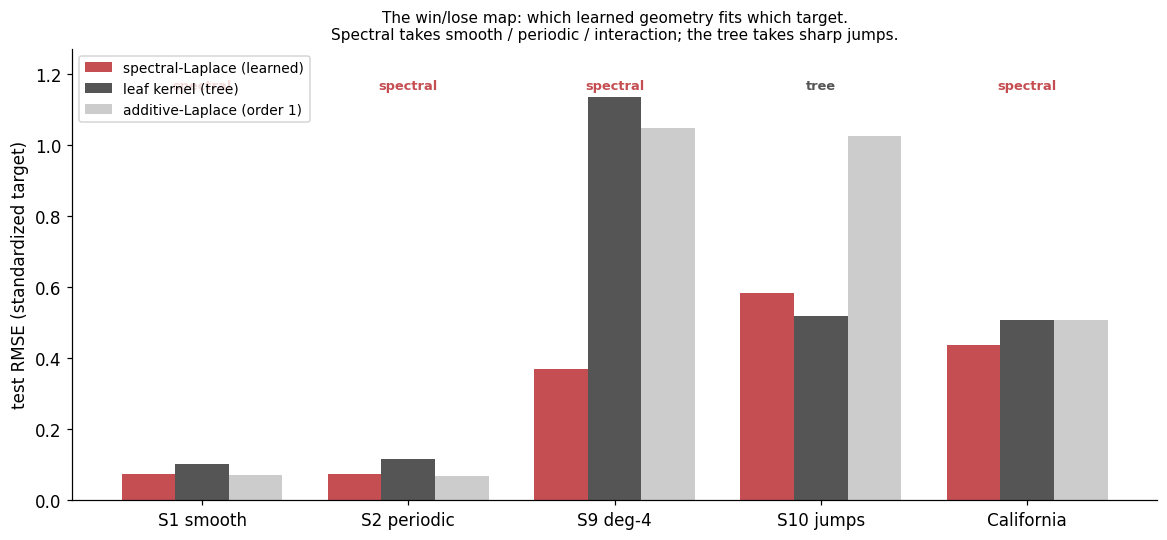

In [6]:
ch09.make_winloss_figure(rows=rows)
plt.show()

Read the map: on **S9** (degree-four interaction) the additive-Laplace control trails the
full spectral kernel badly — the order-one limit cannot represent the interaction, which
comes from the **readout** (the Laplace exponential of an additive distance is a scale
mixture of product kernels). On **S10** (sharp jumps) only the discontinuous leaf kernel
fits the jumps; the continuous spectral smoother pays a Gibbs cost.

## 9.4  Fusing banks adds range, not order

Sweep the number of Laplace banks H from 1 to 8 on a smooth target and an interaction
target. The error does not improve with H: a convex sum of banks is a *union* of function
spaces (the Aronszajn sum), whose ANOVA order set equals a single bank's. Fusion buys
*scale range*, never interaction order.

In [7]:
def h_sweep(key):
    """Re-learn the spectral kernel with H = 1, 2, 4 banks and score on the held-out test fold.
    Every other knob (frequencies, amplitudes, relevance, bandwidths) is re-fit at each H."""
    X, y, _ = ch09.SYNTH[key](n=1500)
    Xtr, ytr, Xte, yte = ch09._split(X, y)
    out = {}
    for H in (1, 2, 4):
        _, pred = ch09.fit_spectral_mv(Xtr, ytr, H=H)
        out[H] = round(ch09._rmse(pred(Xte), yte), 3)
    return out


print("S1 smooth   H-sweep:", h_sweep("S1"))
print("S9 deg-4    H-sweep:", h_sweep("S9"))
# The error is flat in H: fusion is a *range* axis (Aronszajn sum = union of order sets), not an
# order axis. A single Laplace bank already carries every interaction order.

S1 smooth   H-sweep: {1: 0.074, 2: 0.074, 4: 0.073}


S9 deg-4    H-sweep: {1: 0.246, 2: 0.246, 4: 0.246}


## 9.5  Explore: pick a target, see who wins

Move the slider across the four synthetic targets (and California) and watch the three test
RMSEs and the winner. This is the win/lose map, one bar group at a time.

In [8]:
from ipywidgets import interact, Dropdown

_cache = {}


def explore(target="S9 deg-4"):
    key = {"S1 smooth": "S1", "S2 periodic": "S2", "S9 deg-4": "S9",
           "S10 jumps": "S10", "California": "CA"}[target]
    if key not in _cache:
        _cache[key] = (ch09.head_to_head_california() if key == "CA"
                       else ch09.head_to_head_target(key))
    r = _cache[key]
    fig, ax = plt.subplots(figsize=(6.2, 4.2), constrained_layout=True)
    names = ["spectral", "leaf kernel", "additive-Laplace"]
    vals = [r["spectral"], r["tree"], r["additive"]]
    colors = ["#c44e52", "#555555", "#cccccc"]
    bars = ax.bar(names, vals, color=colors)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)
    ax.set_title(f"{r['label']}: winner = {r['winner']}", fontsize=11)
    ax.set_ylabel("test RMSE (standardized)")
    plt.show()


interact(explore, target=Dropdown(
    options=["S1 smooth", "S2 periodic", "S9 deg-4", "S10 jumps", "California"],
    value="S9 deg-4", description="target"));

interactive(children=(Dropdown(description='target', index=2, options=('S1 smooth', 'S2 periodic', 'S9 deg-4',…

## Exercises

Fill in each `# TODO`; the solution is one click away.

**(easy)** Confirm the additive-Laplace control cannot represent the interaction: compare its
test RMSE on S9 against the full spectral kernel's.

In [9]:
# TODO: run head_to_head_target("S9") and compare r["additive"] to r["spectral"]
r_s9 = None
print(r_s9)

None


<details><summary>Solution</summary>

```python
r_s9 = ch09.head_to_head_target("S9")
print(f"spectral {r_s9['spectral']:.3f}  vs  additive-Laplace {r_s9['additive']:.3f}")
assert r_s9["additive"] > r_s9["spectral"]   # the order-one limit trails on the interaction
```
The additive kernel is a sum of per-feature kernels — its RKHS carries main effects only
(H^S = {0} for |S| >= 2), so it cannot reach the degree-four product. The full Laplace
readout of the additive distance is a scale mixture of product kernels, which carries every
interaction order.
</details>

**(⋆)** Interactions are the *readout's* doing. Verify the scale-mixture-of-products identity
from the chapter numerically: for a two-feature summed distance,
exp(−(1/T)√(d₀²+d₁²)) = ∫₀^∞ exp(−d₀²u/T²)·exp(−d₁²u/T²) dμ(u), a positive mixture of
**product** kernels — so a single Laplace bank carries the pairwise interaction, while the
additive sum exp(−d₀/T)+exp(−d₁/T) cannot.

In [10]:
# TODO: pick T, d0, d1; compare the Laplace kernel of the summed distance (LHS) to the mixture
# integral (RHS) over the 1/2-stable density mu, and confirm they match.
lhs = rhs = None
print(lhs, rhs)

None None


<details><summary>Solution</summary>

```python
from scipy.integrate import quad
T, d0, d1 = 1.3, 0.7, 0.4
s = (d0**2 + d1**2) / T**2
lhs = np.exp(-np.sqrt(s))                                  # Laplace kernel of the summed distance
mu = lambda u: (1 / (2 * np.sqrt(np.pi))) * u**-1.5 * np.exp(-1 / (4 * u))   # 1/2-stable density
rhs = quad(lambda u: np.exp(-s * u) * mu(u), 0, np.inf)[0]
print(f"LHS {lhs:.6f}   RHS {rhs:.6f}")
assert abs(lhs - rhs) < 1e-4
```
The integrand factors: exp(−su) = exp(−d₀²u/T²)·exp(−d₁²u/T²) is a **product** of per-feature
Gaussian kernels, so the Laplace kernel of the summed distance is a positive mixture of product
kernels. A product kernel has a nonzero component for every subset of features, and the mixture
preserves them — every interaction order, from one bank. The additive sum is a *sum* of kernels,
so its RKHS is the Aronszajn sum of per-feature spaces: main effects only. That is the whole
difference S9 exposes (Prop. H(1)).
</details>

---
*Companion to Chapter 9 of **The Learned Kernel**. Chapter 9 is carry-over: it **imports**
Chapter 8's canonical learned kernel (`ch08.LearnedSpectralLaplace` / `fit_spectral`, run in the
learned mode via `ch09.fit_spectral_mv`) and adds only the leaf-kernel head-to-head and the
win/lose map, from `lkbook.chapters.ch09` — the same code the book's figures come from. The
book reports the map as mean ± std over ten seeds; here we run a single seed live. The leaf
kernel reuses Chapter 4's `LeafKernel`.*